# 02 Phase 1B — Shape Token + Separate Range Bucket

이 notebook은 Phase 1B의 revised design입니다.

이전 `02_phase_1b_shape_plus_range_scale.ipynb`는 `range_scale_z`를 VQ-VAE encoder 입력에 직접 넣었습니다. 그 결과 range 정보는 token에 잘 반영되었지만, held-out symbol token distribution이 Phase 1A보다 크게 불안정해졌습니다.

따라서 이 notebook에서는 representation을 분리합니다.

```text
shape_token  = 4D price-shape only feature로 학습
range_bucket = train range distribution 기준 별도 bucketizer로 계산

final representation = (shape_token, range_bucket)
```

핵심 질문:

> price-shape token vocabulary는 Phase 1A처럼 안정적으로 유지하면서, range / volatility context를 별도 bucket으로 보존할 수 있는가?

주의:

- 여기서 `shape_token`은 market state token이 아닙니다.
- `range_bucket`은 token의 보조 context입니다.
- future return prediction, trading signal, backtest는 이 notebook 범위 밖입니다.


## 0. Environment Check

필요한 optional dependency:

```bash
uv sync --extra tokenizers
```


In [45]:
from pathlib import Path
import sys


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "modules").is_dir() and (candidate / "research").is_dir():
            return candidate
    raise RuntimeError(
        "FinLabs repo root를 찾지 못했습니다. "
        "notebook을 finlabs repository 안에서 실행하고 있는지 확인하세요."
    )


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)


REPO_ROOT: /Users/choeseoggyu/portfolio/finlabs


In [46]:
%load_ext autoreload
%autoreload 2

print("autoreload enabled")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
autoreload enabled


In [47]:
try:
    import matplotlib.pyplot as plt
    import numpy as np
    import torch
    from sklearn.cluster import KMeans
except ImportError as exc:
    raise RuntimeError(
        "이 notebook은 optional tokenizer dependency, matplotlib, scikit-learn이 필요합니다. "
        "먼저 `uv sync --extra tokenizers`를 실행하세요."
    ) from exc

print("numpy", np.__version__)
print("torch", torch.__version__)


numpy 2.4.4
torch 2.12.0


## 1. Experiment Config

`CODEBOOK_SIZE`는 Phase 1A와 비교 가능하도록 기본값 `12`를 사용합니다.

`RANGE_BUCKET_QUANTILES`는 train split의 `log_range_pct` 분포에서 bucket 경계를 fit합니다. 기본값은 6개 bucket입니다.

```text
very_low, low, normal, high, very_high, extreme
```


In [48]:
import json
import os
import random
from dataclasses import dataclass
from datetime import datetime, timezone
from typing import Iterable, Sequence

from modules.storage.warehouse import default_warehouse_file

MARKET = "NASDAQ"
SYMBOLS = [
    "AAPL",
    "MSFT",
    "NVDA",
    "TSLA",
    "AMZN",
    "META",
    "GOOGL",
    "AMD",
    "INTC",
    "RKLB",
    "AVGO",
    "NFLX",
    "PLTR",
    "MU",
    "QCOM",
    "MRVL"
]
INTERVAL = "1m"

MAX_CANDLES_PER_SYMBOL = 12_000
MIN_CANDLES_PER_SYMBOL = 500
MIN_VOLUME = 2  # volume <= 1 candle은 Phase 1 실험에서 제외합니다.

TRAIN_SYMBOLS: list[str] | None = None
VAL_SYMBOLS: list[str] | None = None
TEST_SYMBOLS: list[str] | None = None

CODEBOOK_SIZE = 12
LATENT_DIM = 16
HIDDEN_DIM = 64
EPOCHS = 25
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
SEED = 42
SPLIT_FAMILY: str | None = None
SPLIT_INDEX: int | None = None
SPLIT_SEED: int = SEED

KMEANS_N_INIT = 20
KMEANS_MAX_ITER = 300

RANGE_BUCKET_QUANTILES = [0.20, 0.40, 0.60, 0.80, 0.95]
RANGE_BUCKET_LABELS = ["very_low", "low", "normal", "high", "very_high", "extreme"]

WAREHOUSE_PATH = default_warehouse_file()
RUN_DIR = REPO_ROOT / "research" / "notebooks" / "01_shape_quantization" / "runs" / "phase_1b" / f"shape_token_range_bucket_{MARKET}_{INTERVAL}_k{CODEBOOK_SIZE}_vge{MIN_VOLUME}"
FIGURES_DIR = RUN_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def set_reproducible_seed(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_reproducible_seed(SEED)

EXPERIMENT_CONFIG = {
    "phase": "1B",
    "experiment": "shape_token_plus_separate_range_bucket",
    "market": MARKET,
    "symbols": SYMBOLS,
    "interval": INTERVAL,
    "max_candles_per_symbol": MAX_CANDLES_PER_SYMBOL,
    "min_candles_per_symbol": MIN_CANDLES_PER_SYMBOL,
    "min_volume": MIN_VOLUME,
    "volume_filter": f"volume >= {MIN_VOLUME}",
    "codebook_size": CODEBOOK_SIZE,
    "latent_dim": LATENT_DIM,
    "hidden_dim": HIDDEN_DIM,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "seed": SEED,
    "kmeans_n_init": KMEANS_N_INIT,
    "kmeans_max_iter": KMEANS_MAX_ITER,
    "range_bucket_quantiles": RANGE_BUCKET_QUANTILES,
    "range_bucket_labels": RANGE_BUCKET_LABELS,
    "warehouse_path": str(WAREHOUSE_PATH),
    "run_dir": str(RUN_DIR),
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "split_family": SPLIT_FAMILY,
    "split_index": SPLIT_INDEX,
    "split_seed": SPLIT_SEED,
    "train_symbols": None,
    "val_symbols": None,
    "test_symbols": None,
}

(RUN_DIR / "experiment_config.json").write_text(
    json.dumps(EXPERIMENT_CONFIG, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("WAREHOUSE_PATH:", WAREHOUSE_PATH)
print("RUN_DIR:", RUN_DIR)
print("FIGURES_DIR:", FIGURES_DIR)


WAREHOUSE_PATH: /Users/choeseoggyu/Library/Application Support/finlabs/warehouse.duckdb
RUN_DIR: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1b/shape_token_range_bucket_NASDAQ_1m_k12
FIGURES_DIR: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1b/shape_token_range_bucket_NASDAQ_1m_k12/figures


## 2. Load Multi-symbol Candles


In [49]:
from collections import Counter, defaultdict
from research.tokenizers.data import CandleBar, filter_by_min_volume, load_candles


def cap_recent(candles: tuple[CandleBar, ...], max_items: int | None) -> tuple[CandleBar, ...]:
    if max_items is None or len(candles) <= max_items:
        return candles
    return candles[-max_items:]


candles_by_symbol: dict[str, tuple[CandleBar, ...]] = {}
missing_symbols: list[str] = []
skipped_symbols: list[tuple[str, int]] = []
volume_filtered_counts: dict[str, int] = {}

for symbol in SYMBOLS:
    candles = load_candles(WAREHOUSE_PATH, market=MARKET, symbol=symbol, interval=INTERVAL)
    raw_count = len(candles)
    candles = filter_by_min_volume(candles, min_volume=MIN_VOLUME)
    volume_filtered_counts[symbol] = raw_count - len(candles)
    candles = cap_recent(candles, MAX_CANDLES_PER_SYMBOL)
    if not candles:
        missing_symbols.append(symbol)
        continue
    if len(candles) < MIN_CANDLES_PER_SYMBOL:
        skipped_symbols.append((symbol, len(candles)))
        continue
    candles_by_symbol[symbol] = candles

print("loaded symbols:", list(candles_by_symbol))
print("counts:", {symbol: len(rows) for symbol, rows in candles_by_symbol.items()})
print("volume filtered counts:", {symbol: count for symbol, count in volume_filtered_counts.items() if count > 0})
print("missing symbols:", missing_symbols)
print("skipped symbols:", skipped_symbols)

EXPERIMENT_CONFIG["volume_filtered_counts"] = {
    symbol: count for symbol, count in sorted(volume_filtered_counts.items()) if count > 0
}

if len(candles_by_symbol) < 3:
    raise RuntimeError("Phase 1B multi-symbol 실험에는 최소 3개 이상의 symbol 데이터가 필요합니다.")


loaded symbols: ['AAPL', 'MSFT', 'NVDA', 'TSLA', 'AMZN', 'META', 'GOOGL', 'AMD', 'INTC', 'RKLB', 'AVGO', 'NFLX', 'PLTR', 'MU', 'QCOM', 'MRVL']
counts: {'AAPL': 12000, 'MSFT': 12000, 'NVDA': 12000, 'TSLA': 12000, 'AMZN': 12000, 'META': 12000, 'GOOGL': 12000, 'AMD': 12000, 'INTC': 12000, 'RKLB': 12000, 'AVGO': 12000, 'NFLX': 12000, 'PLTR': 12000, 'MU': 12000, 'QCOM': 12000, 'MRVL': 12000}
missing symbols: []
skipped symbols: []


## 3. Held-out Symbol Split


In [50]:
def auto_symbol_split(symbols: list[str]) -> tuple[list[str], list[str], list[str]]:
    if len(symbols) < 3:
        raise ValueError("at least 3 symbols are required")
    if len(symbols) < 8:
        import warnings
        warnings.warn(
            f"auto_symbol_split: {len(symbols)} symbols only — val or test may contain a single symbol. "
            "Split-level metrics will be unreliable with fewer than 8 symbols.",
            UserWarning,
            stacklevel=2,
        )
    n = len(symbols)
    train_end = max(1, int(n * 0.7))
    val_end = max(train_end + 1, int(n * 0.85))
    val_end = min(val_end, n - 1)
    return symbols[:train_end], symbols[train_end:val_end], symbols[val_end:]


available_symbols = list(candles_by_symbol)
if TRAIN_SYMBOLS is None or VAL_SYMBOLS is None or TEST_SYMBOLS is None:
    train_symbols, val_symbols, test_symbols = auto_symbol_split(available_symbols)
else:
    train_symbols, val_symbols, test_symbols = TRAIN_SYMBOLS, VAL_SYMBOLS, TEST_SYMBOLS

for group_name, group_symbols in {
    "train": train_symbols,
    "val": val_symbols,
    "test": test_symbols,
}.items():
    unknown = [symbol for symbol in group_symbols if symbol not in candles_by_symbol]
    if unknown:
        raise RuntimeError(f"{group_name} split에 load되지 않은 symbol이 있습니다: {unknown}")

train_candles = tuple(candle for symbol in train_symbols for candle in candles_by_symbol[symbol])
val_candles = tuple(candle for symbol in val_symbols for candle in candles_by_symbol[symbol])
test_candles = tuple(candle for symbol in test_symbols for candle in candles_by_symbol[symbol])

print("train_symbols:", train_symbols)
print("val_symbols:", val_symbols)
print("test_symbols:", test_symbols)
print("train candles:", len(train_candles))
print("val candles:", len(val_candles))
print("test candles:", len(test_candles))

if not train_candles or not val_candles or not test_candles:
    raise RuntimeError("train/val/test split must not be empty")

EXPERIMENT_CONFIG.update({
    "train_symbols": train_symbols,
    "val_symbols": val_symbols,
    "test_symbols": test_symbols,
})
(RUN_DIR / "experiment_config.json").write_text(
    json.dumps(EXPERIMENT_CONFIG, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print("experiment_config.json updated with split symbols")


train_symbols: ['AAPL', 'MSFT', 'NVDA', 'TSLA', 'AMZN', 'META', 'GOOGL', 'AMD', 'INTC', 'RKLB', 'AVGO']
val_symbols: ['NFLX', 'PLTR']
test_symbols: ['MU', 'QCOM', 'MRVL']
train candles: 132000
val candles: 24000
test candles: 36000
experiment_config.json updated with split symbols


## 4. Extract 4D Price-Shape Features

Range는 여기서 shape feature에 섞지 않습니다.


In [51]:
@dataclass(frozen=True, slots=True)
class PriceShapeFeature:
    signed_body_ratio: float
    upper_ratio: float
    lower_ratio: float
    body_center_location: float

    def as_tuple(self) -> tuple[float, float, float, float]:
        return (
            self.signed_body_ratio,
            self.upper_ratio,
            self.lower_ratio,
            self.body_center_location,
        )


FEATURE_NAMES = [
    "signed_body_ratio",
    "upper_ratio",
    "lower_ratio",
    "body_center_location",
]


def direction(open_price: float, close_price: float) -> float:
    if close_price > open_price:
        return 1.0
    if close_price < open_price:
        return -1.0
    return 0.0


def extract_price_shape_feature(candle: CandleBar) -> PriceShapeFeature:
    total_range = max(candle.high - candle.low, 0.0)
    if total_range == 0.0:
        return PriceShapeFeature(0.0, 0.0, 0.0, 0.0)

    body_top = max(candle.open, candle.close)
    body_bottom = min(candle.open, candle.close)
    body_ratio = abs(candle.close - candle.open) / total_range
    signed_body_ratio = body_ratio * direction(candle.open, candle.close)
    upper_ratio = max(candle.high - body_top, 0.0) / total_range
    lower_ratio = max(body_bottom - candle.low, 0.0) / total_range

    body_center = (candle.open + candle.close) / 2.0
    body_center_position = (body_center - candle.low) / total_range
    body_center_location = 2.0 * body_center_position - 1.0

    return PriceShapeFeature(
        signed_body_ratio=float(signed_body_ratio),
        upper_ratio=float(upper_ratio),
        lower_ratio=float(lower_ratio),
        body_center_location=float(body_center_location),
    )


def extract_price_shape_features(candles: Iterable[CandleBar]) -> tuple[PriceShapeFeature, ...]:
    return tuple(extract_price_shape_feature(candle) for candle in candles)


def feature_matrix(features: Sequence[PriceShapeFeature]) -> np.ndarray:
    return np.array([feature.as_tuple() for feature in features], dtype=np.float32)


train_features = extract_price_shape_features(train_candles)
val_features = extract_price_shape_features(val_candles)
test_features = extract_price_shape_features(test_candles)

print("first feature:", train_features[0])
print("input_dim:", len(train_features[0].as_tuple()))


first feature: PriceShapeFeature(signed_body_ratio=0.3695652173912775, upper_ratio=0.5217391304348901, lower_ratio=0.10869565217383245, body_center_location=-0.41304347826081045)
input_dim: 4


## 5. Fit Separate Range Bucketizer

Bucketizer는 train split의 `log_range_pct` 분포로만 fit합니다. val/test는 train thresholds로 transform합니다.


In [52]:
@dataclass(frozen=True, slots=True)
class RangeBucketizer:
    quantiles: tuple[float, ...]
    edges: tuple[float, ...]
    labels: tuple[str, ...]

    def bucket_index(self, raw_log_range_pct: float) -> int:
        return int(np.searchsorted(np.array(self.edges), raw_log_range_pct, side="right"))

    def bucket_label(self, raw_log_range_pct: float) -> str:
        return self.labels[self.bucket_index(raw_log_range_pct)]


def raw_log_range_pct(candle: CandleBar) -> float:
    reference_price = max(abs(candle.open), abs(candle.close), 1e-12)
    range_pct = max(candle.high - candle.low, 0.0) / reference_price
    return float(np.log1p(range_pct))


def fit_range_bucketizer(candles: Sequence[CandleBar]) -> RangeBucketizer:
    values = np.array([raw_log_range_pct(candle) for candle in candles], dtype=np.float64)
    edges = tuple(float(x) for x in np.quantile(values, RANGE_BUCKET_QUANTILES))
    if len(RANGE_BUCKET_LABELS) != len(edges) + 1:
        raise ValueError("number of range bucket labels must be len(edges) + 1")
    return RangeBucketizer(
        quantiles=tuple(float(x) for x in RANGE_BUCKET_QUANTILES),
        edges=edges,
        labels=tuple(RANGE_BUCKET_LABELS),
    )


def encode_range_buckets(candles: Sequence[CandleBar], bucketizer: RangeBucketizer) -> tuple[int, ...]:
    return tuple(bucketizer.bucket_index(raw_log_range_pct(candle)) for candle in candles)


range_bucketizer = fit_range_bucketizer(train_candles)
train_range_buckets = encode_range_buckets(train_candles, range_bucketizer)
val_range_buckets = encode_range_buckets(val_candles, range_bucketizer)
test_range_buckets = encode_range_buckets(test_candles, range_bucketizer)

print("range quantiles:", range_bucketizer.quantiles)
print("range edges:", range_bucketizer.edges)
print("range labels:", range_bucketizer.labels)
print("train range bucket counts:", Counter(train_range_buckets))
print("val range bucket counts:", Counter(val_range_buckets))
print("test range bucket counts:", Counter(test_range_buckets))


range quantiles: (0.2, 0.4, 0.6, 0.8, 0.95)
range edges: (0.0004305220048537388, 0.0007163300521083463, 0.0011043132438550076, 0.0018453178846488643, 0.003748348708218963)
range labels: ('very_low', 'low', 'normal', 'high', 'very_high', 'extreme')
train range bucket counts: Counter({2: 26400, 1: 26400, 3: 26400, 0: 26400, 4: 19800, 5: 6600})
val range bucket counts: Counter({2: 5556, 1: 5269, 3: 5093, 0: 4930, 4: 2581, 5: 571})
test range bucket counts: Counter({4: 12162, 3: 8891, 5: 5484, 2: 4360, 0: 2946, 1: 2157})


## 6. Train VQ-VAE Shape Tokenizer

VQ-VAE는 4D price-shape feature만 학습합니다.


In [53]:
from research.tokenizers.model import VQVAE, VQVAEConfig
from research.tokenizers.train import TrainConfig, train

set_reproducible_seed(SEED)

train_config = TrainConfig(
    output_dir=RUN_DIR,
    model=VQVAEConfig(
        input_dim=len(FEATURE_NAMES),
        codebook_size=CODEBOOK_SIZE,
        latent_dim=LATENT_DIM,
        hidden_dim=HIDDEN_DIM,
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    seed=SEED,
)

result = train(train_features, config=train_config)
print(result)


TrainResult(checkpoint_path=PosixPath('/Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1b/shape_token_range_bucket_NASDAQ_1m_k12/tokenizer.pt'), epochs=25, final_loss=0.06787892431020737)


## 7. Encode Shape Tokens and Combined Pairs


In [54]:
def load_vqvae_model(checkpoint_path: Path):
    checkpoint = torch.load(Path(checkpoint_path), map_location="cpu", weights_only=True)
    model_config = VQVAEConfig(**checkpoint["config"])
    model = VQVAE(model_config)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    return model


def encode_features(model, features: Sequence[PriceShapeFeature]) -> tuple[int, ...]:
    if not features:
        return ()
    inputs = torch.tensor([feature.as_tuple() for feature in features], dtype=torch.float32)
    with torch.no_grad():
        z_e = model.encoder(inputs)
        _z_q_st, _z_q, indices = model.quantizer(z_e)
    return tuple(int(index) for index in indices.cpu().tolist())


def reconstruction_mse(model, features: Sequence[PriceShapeFeature]) -> float:
    if not features:
        return 0.0
    inputs = torch.tensor([feature.as_tuple() for feature in features], dtype=torch.float32)
    with torch.no_grad():
        reconstruction, *_ = model(inputs)
        loss = torch.mean((reconstruction - inputs) ** 2)
    return float(loss.cpu().item())


def combine_shape_range(shape_tokens: Sequence[int], range_buckets: Sequence[int]) -> tuple[tuple[int, int], ...]:
    return tuple((shape, bucket) for shape, bucket in zip(shape_tokens, range_buckets, strict=True))


model = load_vqvae_model(result.checkpoint_path)

train_shape_tokens = encode_features(model, train_features)
val_shape_tokens = encode_features(model, val_features)
test_shape_tokens = encode_features(model, test_features)

train_pairs = combine_shape_range(train_shape_tokens, train_range_buckets)
val_pairs = combine_shape_range(val_shape_tokens, val_range_buckets)
test_pairs = combine_shape_range(test_shape_tokens, test_range_buckets)

print("shape token sample:", train_shape_tokens[:20])
print("range bucket sample:", train_range_buckets[:20])
print("pair sample:", train_pairs[:20])
print("train reconstruction_mse:", round(reconstruction_mse(model, train_features), 6))


shape token sample: (1, 9, 5, 8, 6, 3, 0, 8, 2, 10, 4, 2, 3, 8, 3, 3, 1, 3, 11, 6)
range bucket sample: (2, 4, 1, 1, 3, 2, 1, 3, 2, 2, 1, 1, 0, 2, 2, 1, 1, 1, 0, 2)
pair sample: ((1, 2), (9, 4), (5, 1), (8, 1), (6, 3), (3, 2), (0, 1), (8, 3), (2, 2), (10, 2), (4, 1), (2, 1), (3, 0), (8, 2), (3, 2), (3, 1), (1, 1), (3, 1), (11, 0), (6, 2))
train reconstruction_mse: 0.012679


## 8. Metrics Helpers


In [55]:
from math import log2


def counts_for_ids(values: Sequence[int], *, size: int) -> list[int]:
    hist = Counter(values)
    return [hist.get(i, 0) for i in range(size)]


def ratios_for_ids(values: Sequence[int], *, size: int) -> list[float]:
    counts = np.array(counts_for_ids(values, size=size), dtype=float)
    total = counts.sum()
    if total == 0:
        return [0.0 for _ in range(size)]
    return (counts / total).tolist()


def entropy_from_counts(counts: Sequence[int]) -> float:
    total = sum(counts)
    entropy = 0.0
    if total > 0:
        for count in counts:
            if count > 0:
                probability = count / total
                entropy -= probability * log2(probability)
    return float(entropy)


def token_utilization(values: Sequence[int], *, size: int) -> dict[str, object]:
    histogram = dict(sorted(Counter(values).items()))
    utilized_count = sum(1 for i in range(size) if histogram.get(i, 0) > 0)
    return {
        "size": size,
        "utilized_count": utilized_count,
        "dead_count": size - utilized_count,
        "dead_ratio": (size - utilized_count) / size,
        "entropy": entropy_from_counts(counts_for_ids(values, size=size)),
        "histogram": histogram,
    }


def pair_utilization(pairs: Sequence[tuple[int, int]], *, shape_size: int, bucket_size: int) -> dict[str, object]:
    histogram = dict(sorted(Counter(pairs).items()))
    total_size = shape_size * bucket_size
    utilized_count = len(histogram)
    return {
        "size": total_size,
        "utilized_count": utilized_count,
        "dead_count": total_size - utilized_count,
        "dead_ratio": (total_size - utilized_count) / total_size,
        "entropy": entropy_from_counts(histogram.values()),
        "histogram": {f"{shape}:{bucket}": count for (shape, bucket), count in histogram.items()},
    }


def semantic_consistency(tokens: Sequence[int], features: Sequence[PriceShapeFeature]) -> dict[int, float]:
    groups: dict[int, list[PriceShapeFeature]] = defaultdict(list)
    for token, feature in zip(tokens, features, strict=True):
        groups[token].append(feature)

    result: dict[int, float] = {}
    for token, group in sorted(groups.items()):
        vectors = np.array([feature.as_tuple() for feature in group], dtype=float)
        centroid = vectors.mean(axis=0)
        distances = np.sqrt(((vectors - centroid) ** 2).sum(axis=1))
        result[token] = float(distances.mean())
    return result


def mean_semantic_consistency(tokens: Sequence[int], features: Sequence[PriceShapeFeature]) -> float:
    values = semantic_consistency(tokens, features).values()
    return float(np.mean(list(values))) if values else 0.0


def ratio_diff(lhs: Sequence[int], rhs: Sequence[int], *, size: int) -> dict[str, float]:
    lhs_ratio = np.array(ratios_for_ids(lhs, size=size), dtype=float)
    rhs_ratio = np.array(ratios_for_ids(rhs, size=size), dtype=float)
    diff = np.abs(lhs_ratio - rhs_ratio)
    return {"l1": float(diff.sum()), "max": float(diff.max(initial=0.0))}


def pair_matrix(pairs: Sequence[tuple[int, int]], *, shape_size: int, bucket_size: int) -> np.ndarray:
    matrix = np.zeros((shape_size, bucket_size), dtype=float)
    for shape, bucket in pairs:
        matrix[shape, bucket] += 1
    total = matrix.sum()
    if total > 0:
        matrix /= total
    return matrix


def pair_ratio_diff(lhs: Sequence[tuple[int, int]], rhs: Sequence[tuple[int, int]], *, shape_size: int, bucket_size: int) -> dict[str, float]:
    diff = np.abs(pair_matrix(lhs, shape_size=shape_size, bucket_size=bucket_size) - pair_matrix(rhs, shape_size=shape_size, bucket_size=bucket_size))
    return {"l1": float(diff.sum()), "max": float(diff.max(initial=0.0))}


## 9. Shape Token + Range Bucket Metrics


In [56]:
BUCKET_SIZE = len(RANGE_BUCKET_LABELS)

shape_rows = []
for split, tokens, features in [
    ("train", train_shape_tokens, train_features),
    ("val", val_shape_tokens, val_features),
    ("test", test_shape_tokens, test_features),
]:
    util = token_utilization(tokens, size=CODEBOOK_SIZE)
    shape_rows.append(
        {
            "split": split,
            "count": len(tokens),
            "utilized_count": util["utilized_count"],
            "dead_count": util["dead_count"],
            "dead_ratio": round(float(util["dead_ratio"]), 6),
            "entropy": round(float(util["entropy"]), 6),
            "mean_semantic_consistency": round(mean_semantic_consistency(tokens, features), 6),
            "reconstruction_mse": round(reconstruction_mse(model, features), 6),
            "histogram": util["histogram"],
        }
    )

range_rows = []
for split, buckets in [
    ("train", train_range_buckets),
    ("val", val_range_buckets),
    ("test", test_range_buckets),
]:
    util = token_utilization(buckets, size=BUCKET_SIZE)
    range_rows.append(
        {
            "split": split,
            "count": len(buckets),
            "utilized_count": util["utilized_count"],
            "dead_count": util["dead_count"],
            "dead_ratio": round(float(util["dead_ratio"]), 6),
            "entropy": round(float(util["entropy"]), 6),
            "histogram": util["histogram"],
        }
    )

pair_rows = []
for split, pairs in [
    ("train", train_pairs),
    ("val", val_pairs),
    ("test", test_pairs),
]:
    util = pair_utilization(pairs, shape_size=CODEBOOK_SIZE, bucket_size=BUCKET_SIZE)
    pair_rows.append(
        {
            "split": split,
            "count": len(pairs),
            "utilized_count": util["utilized_count"],
            "dead_count": util["dead_count"],
            "dead_ratio": round(float(util["dead_ratio"]), 6),
            "entropy": round(float(util["entropy"]), 6),
            "histogram": util["histogram"],
        }
    )

print("shape rows")
for row in shape_rows:
    print(row)
print("range bucket rows")
for row in range_rows:
    print(row)
print("pair rows")
for row in pair_rows:
    print(row)

print("shape val/train diff:", ratio_diff(val_shape_tokens, train_shape_tokens, size=CODEBOOK_SIZE))
print("shape test/train diff:", ratio_diff(test_shape_tokens, train_shape_tokens, size=CODEBOOK_SIZE))
print("range val/train diff:", ratio_diff(val_range_buckets, train_range_buckets, size=BUCKET_SIZE))
print("range test/train diff:", ratio_diff(test_range_buckets, train_range_buckets, size=BUCKET_SIZE))
print("pair val/train diff:", pair_ratio_diff(val_pairs, train_pairs, shape_size=CODEBOOK_SIZE, bucket_size=BUCKET_SIZE))
print("pair test/train diff:", pair_ratio_diff(test_pairs, train_pairs, shape_size=CODEBOOK_SIZE, bucket_size=BUCKET_SIZE))


shape rows
{'split': 'train', 'count': 132000, 'utilized_count': 12, 'dead_count': 0, 'dead_ratio': 0.0, 'entropy': 3.468743, 'mean_semantic_consistency': 0.195891, 'reconstruction_mse': 0.012679, 'histogram': {0: 7034, 1: 12179, 2: 13548, 3: 13467, 4: 9248, 5: 10438, 6: 11857, 7: 1533, 8: 16311, 9: 16742, 10: 10468, 11: 9175}}
{'split': 'val', 'count': 24000, 'utilized_count': 12, 'dead_count': 0, 'dead_ratio': 0.0, 'entropy': 3.503848, 'mean_semantic_consistency': 0.196225, 'reconstruction_mse': 0.012538, 'histogram': {0: 1266, 1: 2047, 2: 2433, 3: 2238, 4: 2113, 5: 1761, 6: 1930, 7: 739, 8: 3034, 9: 3148, 10: 1800, 11: 1491}}
{'split': 'test', 'count': 36000, 'utilized_count': 12, 'dead_count': 0, 'dead_ratio': 0.0, 'entropy': 3.478429, 'mean_semantic_consistency': 0.195, 'reconstruction_mse': 0.012118, 'histogram': {0: 1797, 1: 3118, 2: 3429, 3: 3479, 4: 2314, 5: 2574, 6: 3081, 7: 1097, 8: 5072, 9: 5200, 10: 2633, 11: 2206}}
range bucket rows
{'split': 'train', 'count': 132000, 'ut

## 10. KMeans Shape Baseline

KMeans도 4D price-shape feature에만 fit합니다. range bucket은 동일한 bucketizer를 붙입니다.


In [57]:
x_train = feature_matrix(train_features)
x_val = feature_matrix(val_features)
x_test = feature_matrix(test_features)

kmeans_model = KMeans(
    n_clusters=CODEBOOK_SIZE,
    random_state=SEED,
    n_init=KMEANS_N_INIT,
    max_iter=KMEANS_MAX_ITER,
)
kmeans_train_shape_tokens = tuple(int(x) for x in kmeans_model.fit_predict(x_train).tolist())
kmeans_val_shape_tokens = tuple(int(x) for x in kmeans_model.predict(x_val).tolist())
kmeans_test_shape_tokens = tuple(int(x) for x in kmeans_model.predict(x_test).tolist())

kmeans_train_pairs = combine_shape_range(kmeans_train_shape_tokens, train_range_buckets)
kmeans_val_pairs = combine_shape_range(kmeans_val_shape_tokens, val_range_buckets)
kmeans_test_pairs = combine_shape_range(kmeans_test_shape_tokens, test_range_buckets)

print("KMeans shape train utilization:", token_utilization(kmeans_train_shape_tokens, size=CODEBOOK_SIZE))
print("KMeans shape val/train diff:", ratio_diff(kmeans_val_shape_tokens, kmeans_train_shape_tokens, size=CODEBOOK_SIZE))
print("KMeans shape test/train diff:", ratio_diff(kmeans_test_shape_tokens, kmeans_train_shape_tokens, size=CODEBOOK_SIZE))
print("KMeans pair val/train diff:", pair_ratio_diff(kmeans_val_pairs, kmeans_train_pairs, shape_size=CODEBOOK_SIZE, bucket_size=BUCKET_SIZE))
print("KMeans pair test/train diff:", pair_ratio_diff(kmeans_test_pairs, kmeans_train_pairs, shape_size=CODEBOOK_SIZE, bucket_size=BUCKET_SIZE))
kmeans_train_mean_sc = mean_semantic_consistency(kmeans_train_shape_tokens, train_features)
kmeans_val_mean_sc = mean_semantic_consistency(kmeans_val_shape_tokens, val_features)
kmeans_test_mean_sc = mean_semantic_consistency(kmeans_test_shape_tokens, test_features)
print("KMeans shape mean_semantic_consistency train:", round(kmeans_train_mean_sc, 6))
print("KMeans shape mean_semantic_consistency val:  ", round(kmeans_val_mean_sc, 6))
print("KMeans shape mean_semantic_consistency test: ", round(kmeans_test_mean_sc, 6))

KMeans shape train utilization: {'size': 12, 'utilized_count': 12, 'dead_count': 0, 'dead_ratio': 0.0, 'entropy': 3.5387286430853786, 'histogram': {0: 11222, 1: 10453, 2: 9960, 3: 7750, 4: 8640, 5: 18773, 6: 14963, 7: 10186, 8: 9650, 9: 11630, 10: 8593, 11: 10180}}
KMeans shape val/train diff: {'l1': 0.07718181818181814, 'max': 0.016935606060606068}
KMeans shape test/train diff: {'l1': 0.09559595959595955, 'max': 0.017782828282828275}
KMeans pair val/train diff: {'l1': 0.19665909090909092, 'max': 0.01758712121212121}
KMeans pair test/train diff: {'l1': 0.7011464646464647, 'max': 0.029434343434343434}
KMeans shape mean_semantic_consistency train: 0.209735
KMeans shape mean_semantic_consistency val:   0.214731
KMeans shape mean_semantic_consistency test:  0.21449


## 11. Per-symbol Metrics


In [58]:
def group_by_symbol(
    candles: Sequence[CandleBar],
    shape_tokens: Sequence[int],
    range_buckets: Sequence[int],
) -> dict[str, dict[str, object]]:
    rows: dict[str, dict[str, object]] = {}
    for candle, shape_token, range_bucket in zip(candles, shape_tokens, range_buckets, strict=True):
        entry = rows.setdefault(candle.symbol, {"shape_tokens": [], "range_buckets": [], "pairs": []})
        entry["shape_tokens"].append(shape_token)
        entry["range_buckets"].append(range_bucket)
        entry["pairs"].append((shape_token, range_bucket))
    return rows


all_candles = train_candles + val_candles + test_candles
all_shape_tokens = train_shape_tokens + val_shape_tokens + test_shape_tokens
all_range_buckets = train_range_buckets + val_range_buckets + test_range_buckets
per_symbol = group_by_symbol(all_candles, all_shape_tokens, all_range_buckets)

per_symbol_rows = []
for symbol, payload in sorted(per_symbol.items()):
    shape_tokens = tuple(payload["shape_tokens"])
    range_buckets = tuple(payload["range_buckets"])
    pairs = tuple(payload["pairs"])
    shape_util = token_utilization(shape_tokens, size=CODEBOOK_SIZE)
    range_util = token_utilization(range_buckets, size=BUCKET_SIZE)
    pair_util = pair_utilization(pairs, shape_size=CODEBOOK_SIZE, bucket_size=BUCKET_SIZE)
    per_symbol_rows.append(
        {
            "symbol": symbol,
            "count": len(shape_tokens),
            "shape_entropy": round(float(shape_util["entropy"]), 6),
            "range_entropy": round(float(range_util["entropy"]), 6),
            "pair_entropy": round(float(pair_util["entropy"]), 6),
            "shape_histogram": shape_util["histogram"],
            "range_histogram": range_util["histogram"],
            "pair_utilized_count": pair_util["utilized_count"],
        }
    )

for row in per_symbol_rows:
    print(row)


{'symbol': 'AAPL', 'count': 12000, 'shape_entropy': 3.46579, 'range_entropy': 2.12657, 'pair_entropy': 5.542492, 'shape_histogram': {0: 628, 1: 1084, 2: 1126, 3: 1121, 4: 882, 5: 821, 6: 970, 7: 221, 8: 1667, 9: 1658, 10: 1123, 11: 699}, 'range_histogram': {0: 4209, 1: 3375, 2: 2306, 3: 1523, 4: 480, 5: 107}, 'pair_utilized_count': 67}
{'symbol': 'AMD', 'count': 12000, 'shape_entropy': 3.441105, 'range_entropy': 2.327473, 'pair_entropy': 5.722934, 'shape_histogram': {0: 643, 1: 1248, 2: 1216, 3: 1396, 4: 704, 5: 1095, 6: 1162, 7: 30, 8: 1293, 9: 1266, 10: 954, 11: 993}, 'range_histogram': {0: 618, 1: 1139, 2: 1924, 3: 3538, 4: 3662, 5: 1119}, 'pair_utilized_count': 67}
{'symbol': 'AMZN', 'count': 12000, 'shape_entropy': 3.465893, 'range_entropy': 2.268736, 'pair_entropy': 5.689814, 'shape_histogram': {0: 659, 1: 1042, 2: 1136, 3: 1182, 4: 950, 5: 846, 6: 929, 7: 170, 8: 1546, 9: 1637, 10: 1177, 11: 726}, 'range_histogram': {0: 3030, 1: 3073, 2: 2897, 3: 2049, 4: 829, 5: 122}, 'pair_uti

## 12. Save Metrics


In [59]:
METRICS = {
    "config": EXPERIMENT_CONFIG,
    "feature": {
        "shape_feature_names": FEATURE_NAMES,
        "range_bucketizer": {
            "quantiles": range_bucketizer.quantiles,
            "edges": range_bucketizer.edges,
            "labels": range_bucketizer.labels,
        },
    },
    "split": {
        "train_symbols": train_symbols,
        "val_symbols": val_symbols,
        "test_symbols": test_symbols,
        "train_candles": len(train_candles),
        "val_candles": len(val_candles),
        "test_candles": len(test_candles),
    },
    "vqvae_shape": {
        "train_result": {
            "checkpoint_path": str(result.checkpoint_path),
            "epochs": result.epochs,
            "final_loss": result.final_loss,
        },
        "rows": shape_rows,
        "val_train_ratio_diff": ratio_diff(val_shape_tokens, train_shape_tokens, size=CODEBOOK_SIZE),
        "test_train_ratio_diff": ratio_diff(test_shape_tokens, train_shape_tokens, size=CODEBOOK_SIZE),
    },
    "range_bucket": {
        "rows": range_rows,
        "val_train_ratio_diff": ratio_diff(val_range_buckets, train_range_buckets, size=BUCKET_SIZE),
        "test_train_ratio_diff": ratio_diff(test_range_buckets, train_range_buckets, size=BUCKET_SIZE),
    },
    "shape_range_pair": {
        "rows": pair_rows,
        "val_train_ratio_diff": pair_ratio_diff(val_pairs, train_pairs, shape_size=CODEBOOK_SIZE, bucket_size=BUCKET_SIZE),
        "test_train_ratio_diff": pair_ratio_diff(test_pairs, train_pairs, shape_size=CODEBOOK_SIZE, bucket_size=BUCKET_SIZE),
    },
    "kmeans_shape": {
        "params": kmeans_model.get_params(),
        "inertia_total": float(kmeans_model.inertia_),
        "inertia_per_sample": float(kmeans_model.inertia_ / len(x_train)),
        "shape_val_train_ratio_diff": ratio_diff(kmeans_val_shape_tokens, kmeans_train_shape_tokens, size=CODEBOOK_SIZE),
        "shape_test_train_ratio_diff": ratio_diff(kmeans_test_shape_tokens, kmeans_train_shape_tokens, size=CODEBOOK_SIZE),
        "pair_val_train_ratio_diff": pair_ratio_diff(kmeans_val_pairs, kmeans_train_pairs, shape_size=CODEBOOK_SIZE, bucket_size=BUCKET_SIZE),
        "pair_test_train_ratio_diff": pair_ratio_diff(kmeans_test_pairs, kmeans_train_pairs, shape_size=CODEBOOK_SIZE, bucket_size=BUCKET_SIZE),
        "mean_semantic_consistency_train": kmeans_train_mean_sc,
        "mean_semantic_consistency_val": kmeans_val_mean_sc,
        "mean_semantic_consistency_test": kmeans_test_mean_sc,
    },
    "per_symbol": per_symbol_rows,
}

metrics_path = RUN_DIR / "metrics.json"
metrics_path.write_text(json.dumps(METRICS, ensure_ascii=False, indent=2), encoding="utf-8")
print("saved:", metrics_path)


saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1b/shape_token_range_bucket_NASDAQ_1m_k12/metrics.json


## 13. Visual Diagnostics


In [60]:
def save_current_figure(filename: str) -> Path:
    path = FIGURES_DIR / filename
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print("saved:", path)
    return path


print("FIGURES_DIR:", FIGURES_DIR)


FIGURES_DIR: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1b/shape_token_range_bucket_NASDAQ_1m_k12/figures


### 13.1 Shape Token Ratio


saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1b/shape_token_range_bucket_NASDAQ_1m_k12/figures/01_shape_token_ratio_histogram.png


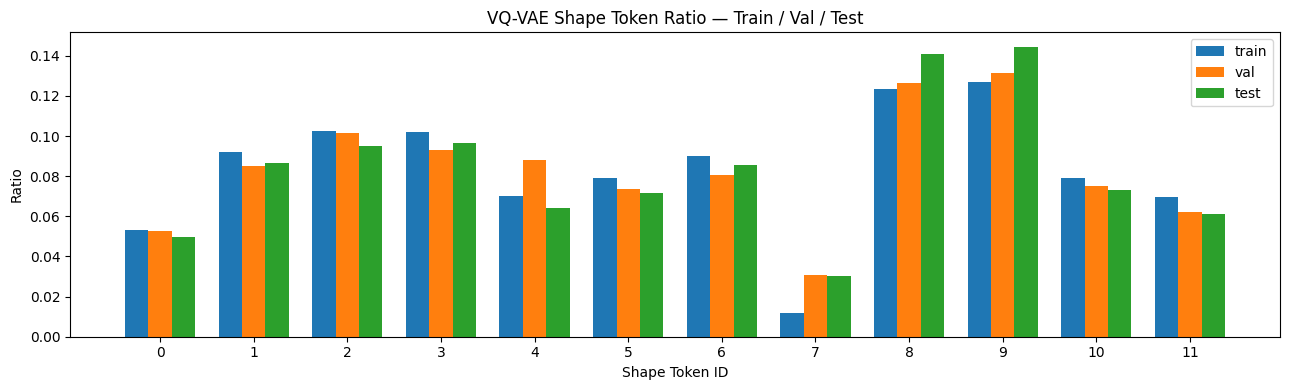

In [61]:
x = np.arange(CODEBOOK_SIZE)
width = 0.25
plt.figure(figsize=(13, 4))
plt.bar(x - width, ratios_for_ids(train_shape_tokens, size=CODEBOOK_SIZE), width=width, label="train")
plt.bar(x, ratios_for_ids(val_shape_tokens, size=CODEBOOK_SIZE), width=width, label="val")
plt.bar(x + width, ratios_for_ids(test_shape_tokens, size=CODEBOOK_SIZE), width=width, label="test")
plt.title("VQ-VAE Shape Token Ratio — Train / Val / Test")
plt.xlabel("Shape Token ID")
plt.ylabel("Ratio")
plt.xticks(range(CODEBOOK_SIZE))
plt.legend()
plt.tight_layout()
save_current_figure("01_shape_token_ratio_histogram.png")
plt.show()


### 13.2 Range Bucket Ratio


saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1b/shape_token_range_bucket_NASDAQ_1m_k12/figures/02_range_bucket_ratio_histogram.png


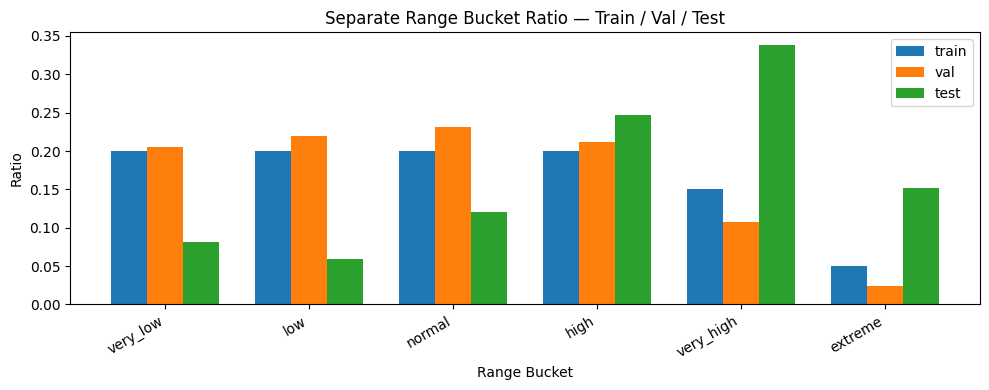

In [62]:
x = np.arange(BUCKET_SIZE)
plt.figure(figsize=(10, 4))
plt.bar(x - width, ratios_for_ids(train_range_buckets, size=BUCKET_SIZE), width=width, label="train")
plt.bar(x, ratios_for_ids(val_range_buckets, size=BUCKET_SIZE), width=width, label="val")
plt.bar(x + width, ratios_for_ids(test_range_buckets, size=BUCKET_SIZE), width=width, label="test")
plt.title("Separate Range Bucket Ratio — Train / Val / Test")
plt.xlabel("Range Bucket")
plt.ylabel("Ratio")
plt.xticks(range(BUCKET_SIZE), RANGE_BUCKET_LABELS, rotation=30, ha="right")
plt.legend()
plt.tight_layout()
save_current_figure("02_range_bucket_ratio_histogram.png")
plt.show()


### 13.3 Shape × Range Pair Heatmap


/var/folders/mz/jtczggb14gxbvk6zysqsfthh0000gn/T/ipykernel_85070/4116174616.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1b/shape_token_range_bucket_NASDAQ_1m_k12/figures/03_shape_range_pair_heatmap.png


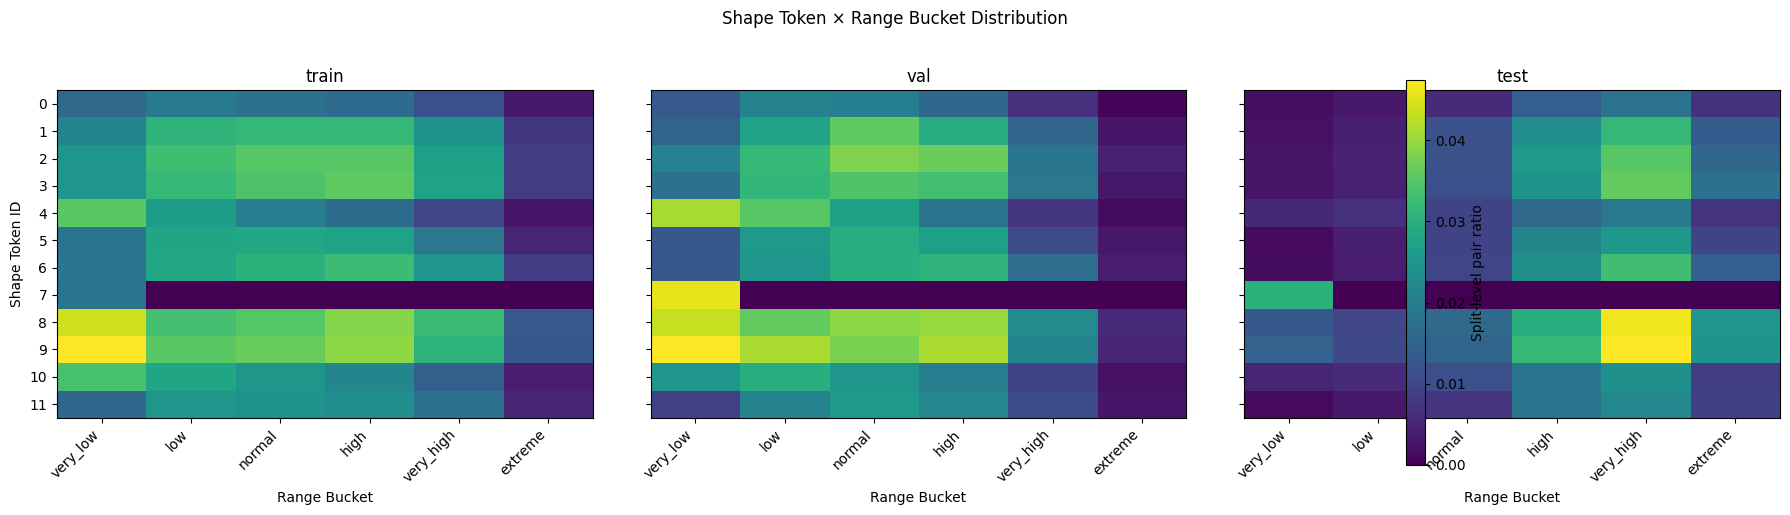

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, title, pairs in [
    (axes[0], "train", train_pairs),
    (axes[1], "val", val_pairs),
    (axes[2], "test", test_pairs),
]:
    matrix = pair_matrix(pairs, shape_size=CODEBOOK_SIZE, bucket_size=BUCKET_SIZE)
    im = ax.imshow(matrix, aspect="auto", cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("Range Bucket")
    ax.set_xticks(range(BUCKET_SIZE), RANGE_BUCKET_LABELS, rotation=45, ha="right")
    ax.set_yticks(range(CODEBOOK_SIZE), range(CODEBOOK_SIZE))
axes[0].set_ylabel("Shape Token ID")
fig.colorbar(im, ax=axes, label="Split-level pair ratio")
fig.suptitle("Shape Token × Range Bucket Distribution", y=1.02)
plt.tight_layout()
save_current_figure("03_shape_range_pair_heatmap.png")
plt.show()


### 13.4 Per-symbol Range Bucket Heatmap


saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1b/shape_token_range_bucket_NASDAQ_1m_k12/figures/04_per_symbol_range_bucket_heatmap.png


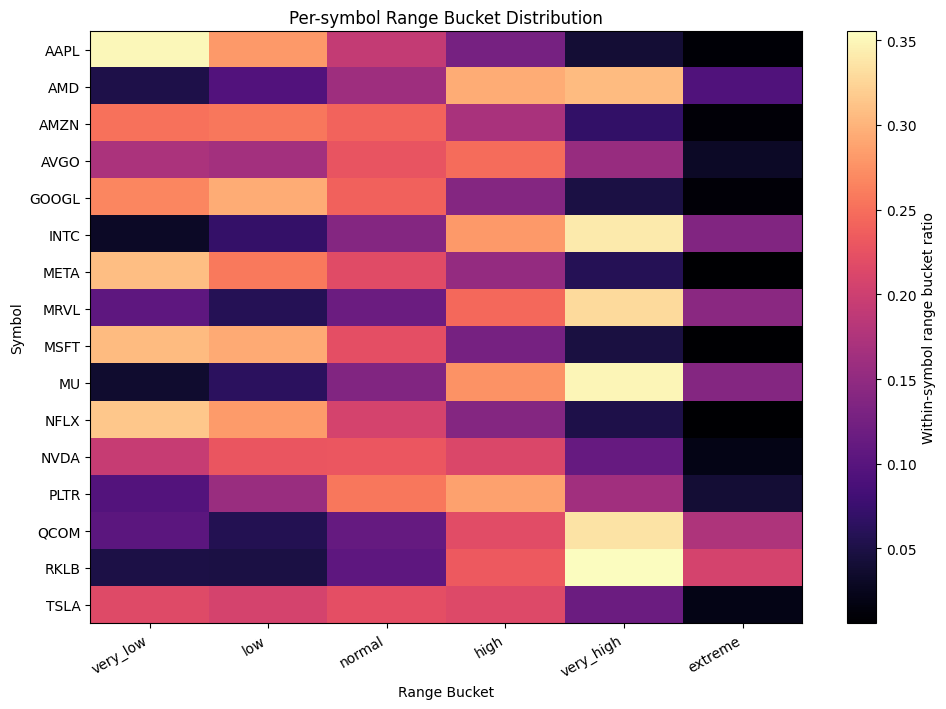

In [64]:
symbols_for_plot = sorted(per_symbol)
range_heatmap = np.zeros((len(symbols_for_plot), BUCKET_SIZE), dtype=float)
for row_index, symbol in enumerate(symbols_for_plot):
    buckets = tuple(per_symbol[symbol]["range_buckets"])
    counts = np.array(counts_for_ids(buckets, size=BUCKET_SIZE), dtype=float)
    total = counts.sum()
    if total > 0:
        range_heatmap[row_index, :] = counts / total

plt.figure(figsize=(10, max(4, len(symbols_for_plot) * 0.45)))
plt.imshow(range_heatmap, aspect="auto", cmap="magma")
plt.colorbar(label="Within-symbol range bucket ratio")
plt.yticks(range(len(symbols_for_plot)), symbols_for_plot)
plt.xticks(range(BUCKET_SIZE), RANGE_BUCKET_LABELS, rotation=30, ha="right")
plt.title("Per-symbol Range Bucket Distribution")
plt.xlabel("Range Bucket")
plt.ylabel("Symbol")
plt.tight_layout()
save_current_figure("04_per_symbol_range_bucket_heatmap.png")
plt.show()


### 13.5 Per-symbol Shape Token Heatmap


saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1b/shape_token_range_bucket_NASDAQ_1m_k12/figures/05_per_symbol_shape_token_heatmap.png


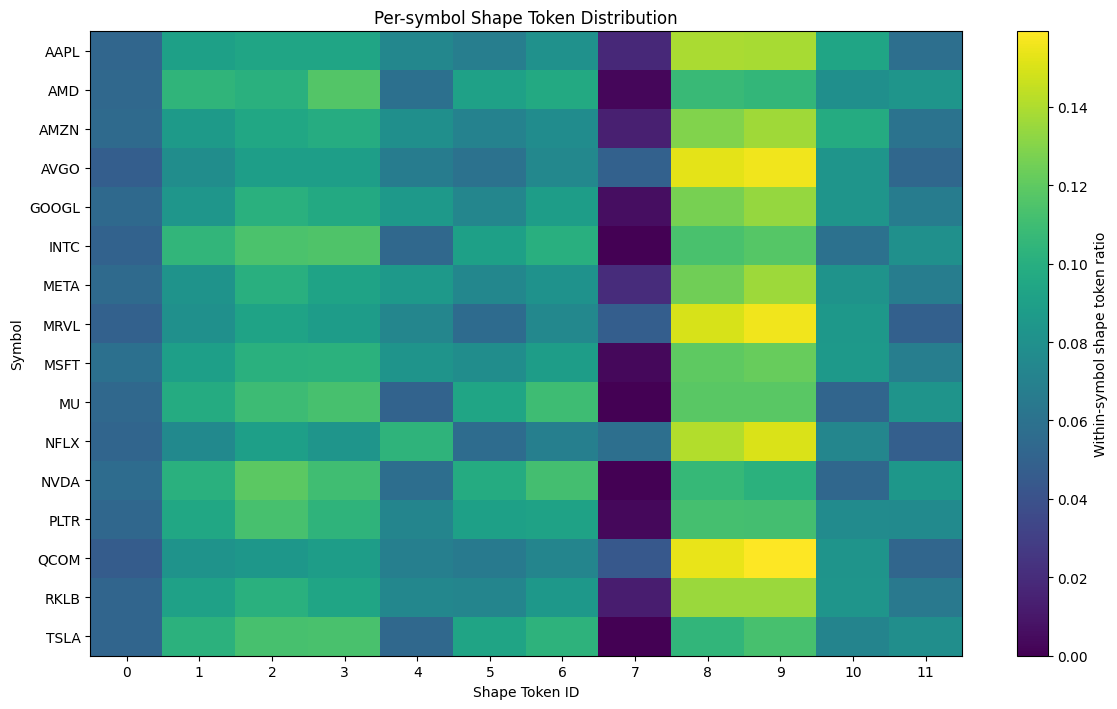

In [65]:
shape_heatmap = np.zeros((len(symbols_for_plot), CODEBOOK_SIZE), dtype=float)
for row_index, symbol in enumerate(symbols_for_plot):
    tokens = tuple(per_symbol[symbol]["shape_tokens"])
    counts = np.array(counts_for_ids(tokens, size=CODEBOOK_SIZE), dtype=float)
    total = counts.sum()
    if total > 0:
        shape_heatmap[row_index, :] = counts / total

plt.figure(figsize=(12, max(4, len(symbols_for_plot) * 0.45)))
plt.imshow(shape_heatmap, aspect="auto", cmap="viridis")
plt.colorbar(label="Within-symbol shape token ratio")
plt.yticks(range(len(symbols_for_plot)), symbols_for_plot)
plt.xticks(range(CODEBOOK_SIZE), range(CODEBOOK_SIZE))
plt.title("Per-symbol Shape Token Distribution")
plt.xlabel("Shape Token ID")
plt.ylabel("Symbol")
plt.tight_layout()
save_current_figure("05_per_symbol_shape_token_heatmap.png")
plt.show()


### 13.6 VQ-VAE vs KMeans Shape Token Distribution


saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1b/shape_token_range_bucket_NASDAQ_1m_k12/figures/06_vqvae_vs_kmeans_shape_histogram.png


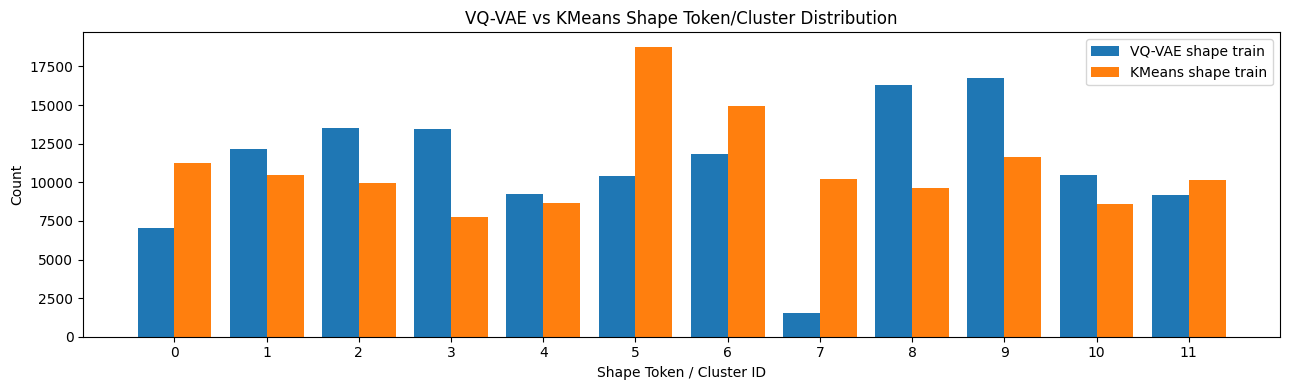

In [66]:
x = np.arange(CODEBOOK_SIZE)
plt.figure(figsize=(13, 4))
plt.bar(x - 0.2, counts_for_ids(train_shape_tokens, size=CODEBOOK_SIZE), width=0.4, label="VQ-VAE shape train")
plt.bar(x + 0.2, counts_for_ids(kmeans_train_shape_tokens, size=CODEBOOK_SIZE), width=0.4, label="KMeans shape train")
plt.title("VQ-VAE vs KMeans Shape Token/Cluster Distribution")
plt.xlabel("Shape Token / Cluster ID")
plt.ylabel("Count")
plt.xticks(range(CODEBOOK_SIZE))
plt.legend()
plt.tight_layout()
save_current_figure("06_vqvae_vs_kmeans_shape_histogram.png")
plt.show()


## 14. Interpretation Checklist

이 notebook은 다음 기준으로 해석합니다.

1. shape token distribution이 Phase 1A처럼 안정적인가?
2. range bucket distribution은 symbol별 volatility 차이를 별도 context로 드러내는가?
3. `(shape_token, range_bucket)` pair가 너무 sparse하지 않은가?
4. range를 encoder에 직접 넣었던 실험보다 held-out shape token 분포가 안정적인가?
5. Phase 2에서는 `shape_token` sequence와 `(shape_token, range_bucket)` sequence를 분리해서 비교할 수 있는가?

가능한 주장:

```text
price-shape vocabulary와 range context를 분리한 representation 후보를 만들었다.
```

아직 하면 안 되는 주장:

```text
market state를 발견했다.
미래 수익률을 예측한다.
매매 신호를 만들었다.
```
